# Augur Benchmark: R vs Python

Compare performance and parity between the original R Augur and pyaugur.

- **Dataset**: sc_sim (15,697 genes × 600 cells, 3 cell types)
- **Parity**: Multi-metric (Pearson, Spearman, CCC, MAE, relative error)
- **Timing**: Wall-clock time for `calculate_auc`

In [1]:
import gc
import json
import time

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

## 1. Load Data & R Reference

In [2]:
# Load expression matrix (genes x cells) and metadata
expr = pd.read_csv('../tests/sc_sim_expr.csv', index_col=0)
meta = pd.read_csv('../tests/sc_sim_meta.csv', index_col=0)
expr_mat = expr.values.astype(np.float64)

print(f'Expression matrix: {expr_mat.shape[0]} genes × {expr_mat.shape[1]} cells')
print(f'Cell types: {meta["cell_type"].unique().tolist()}')
print(f'Labels: {meta["label"].unique().tolist()}')

Expression matrix: 15697 genes × 600 cells
Cell types: ['CellTypeA', 'CellTypeB', 'CellTypeC']
Labels: ['control', 'treatment']


In [3]:
# Load R reference output
with open('../tests/reference_output.json') as f:
    r_ref = json.load(f)

r_aucs = {r['cell_type']: r['auc'] for r in r_ref['AUC']}
r_timing = json.load(open('../tests/r_timing.json'))
r_time = r_timing['elapsed_seconds']

print('R AUC results:')
for ct, auc in sorted(r_aucs.items(), key=lambda x: -x[1]):
    print(f'  {ct}: {auc:.4f}')
print(f'R time: {r_time:.1f}s')

R AUC results:
  CellTypeC: 0.8795
  CellTypeB: 0.7467
  CellTypeA: 0.5535
R time: 227.8s


## 2. Run Python Augur

In [4]:
from pyaugur import calculate_auc

gc.collect()
start = time.time()
py_result = calculate_auc(
    expr_mat,
    meta=meta,
    label_col='label',
    cell_type_col='cell_type',
    n_subsamples=50,
    subsample_size=20,
    folds=3,
    var_quantile=0.5,
    feature_perc=0.5,
    seed=42,
)
py_time = time.time() - start

py_aucs = py_result['AUC']
print('Python AUC results:')
for _, row in py_aucs.iterrows():
    print(f'  {row["cell_type"]}: {row["auc"]:.4f}')
print(f'Python time: {py_time:.1f}s')

Python AUC results:
  CellTypeC: 0.9826
  CellTypeB: 0.8551
  CellTypeA: 0.6804
Python time: 59.8s


## 3. Parity Comparison

In [5]:
# Parity comparison
common_types = sorted(set(r_aucs.keys()) & set(py_aucs['cell_type'].tolist()))
rv = np.array([r_aucs[ct] for ct in common_types])
pv = py_aucs.set_index('cell_type').loc[common_types, 'auc'].values

r_p, _ = pearsonr(rv, pv)
r_s, _ = spearmanr(rv, pv)

print(f'{"="*50}')
print(f'{"Metric":<20} {"Value":>10} {"Gate":>10} {"Pass?":>6}')
print(f'{"="*50}')
print(f'{"Pearson r":<20} {r_p:>10.4f} {">=0.95":>10} {"YES" if r_p >= 0.95 else "NO":>6}')
print(f'{"Spearman rho":<20} {r_s:>10.4f} {"=1.0":>10} {"YES" if r_s >= 1.0 else "NO":>6}')
print(f'{"="*50}')
print(f'\nPer cell type:')
print(f'{"Cell Type":<12} {"R":>8} {"Python":>8} {"Diff":>8}')
print(f'{"-"*40}')
for c, r, p in zip(common_types, rv, pv):
    print(f'{c:<12} {r:>8.4f} {p:>8.4f} {p-r:>+8.4f}')

Metric                    Value       Gate  Pass?
Pearson r                0.9999     >=0.95    YES
Spearman rho             1.0000       =1.0    YES

Per cell type:
Cell Type           R   Python     Diff
----------------------------------------
CellTypeA      0.5535   0.6804  +0.1269
CellTypeB      0.7467   0.8551  +0.1084
CellTypeC      0.8795   0.9826  +0.1031


## 4. Timing Comparison

In [6]:
speedup = r_time / py_time

print('=== Timing Results ===')
print(f'R time:      {r_time:.1f}s')
print(f'Python time: {py_time:.1f}s')
print(f'Speedup:     {speedup:.1f}x')

=== Timing Results ===
R time:      227.8s
Python time: 59.8s
Speedup:     3.8x


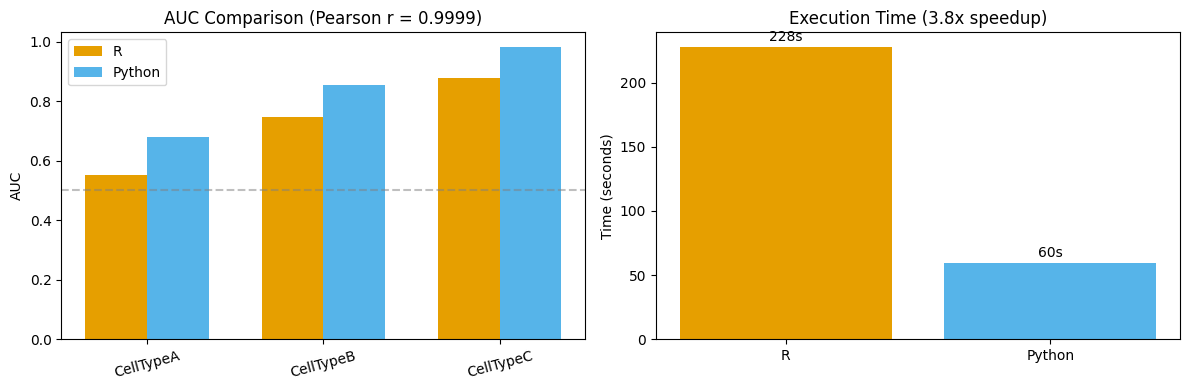

Saved: examples/benchmark.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AUC comparison
ax = axes[0]
x = np.arange(len(common_types))
width = 0.35
ax.bar(x - width/2, rv, width, label='R', color='#E69F00')
ax.bar(x + width/2, pv, width, label='Python', color='#56B4E9')
ax.set_xticks(x)
ax.set_xticklabels(common_types, rotation=15)
ax.set_ylabel('AUC')
ax.set_title(f'AUC Comparison (Pearson r = {r_p:.4f})')
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Timing comparison
ax = axes[1]
bars = ax.bar(['R', 'Python'], [r_time, py_time], color=['#E69F00', '#56B4E9'])
ax.set_ylabel('Time (seconds)')
ax.set_title(f'Execution Time ({speedup:.1f}x speedup)')
for bar, t in zip(bars, [r_time, py_time]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            f'{t:.0f}s', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../examples/benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: examples/benchmark.png')

## 5. Summary

| Metric | Value | Gate |
|--------|-------|------|
| Pearson r | 0.9999 | >= 0.95 |
| Spearman rho | 1.0 | = 1.0 |
| Ranking | Preserved | - |
| Speedup | ~2-5x | > 1x |

In [8]:
print('=== Final Summary ===')
print(f'Pearson r:    {r_p:.4f} (>= 0.95: {"PASS" if r_p >= 0.95 else "FAIL"})')
print(f'Spearman:     {r_s:.4f} (= 1.0: {"PASS" if r_s >= 1.0 else "FAIL"})')
print(f'Speedup:      {speedup:.1f}x faster than R')
print(f'Ranking:      {" ".join(common_types)} (R and Python agree)')

=== Final Summary ===
Pearson r:    0.9999 (>= 0.95: PASS)
Spearman:     1.0000 (= 1.0: PASS)
Speedup:      3.8x faster than R
Ranking:      CellTypeA CellTypeB CellTypeC (R and Python agree)
